# <span style="color:green; font-size:100%;">Pravin Oli (u1999699), Gebrecherkos Gebreslassie (u1999542)</span>

# <span style="color:blue; font-size:100%;">Sampling-Based Algorithms: RRT and RRT*</span>

This notebook contains the implementation of **Sampling-based algorithms**:
- **Rapidly-exploring Random Tree (RRT)**
- **Rapidly-exploring Random Tree Star (RRT\*)**

The objective is to find a path from a <span style="color:green;">**Start**</span> to a <span style="color:red;">**Goal**</span> in all given map environment.

---

This notebook is divided into **3 Parts**:

1. <span style="color:blue;">**Map Loading**</span>:  
   _Load and visualize the different maps where we implement RRT and RRT*._

2. <span style="color:blue;">**RRT Implementation**</span>:  
   _Algorithm to explore the map environment to find a feasible path from Start to Goal._

3. <span style="color:blue;">**RRT\* Implementation**</span>:  
   _An enhanced version of RRT with optimization to find the shortest path._


## <span style="color:blue;">Part A: Map Loading</span>
**Load the map and set up the environment.**
---

In [1]:
# Import necessary Libraries
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import random

In [2]:
# Map configurations: stores file names and start/goal points for each map
maps = {
    0: {"filename": "map0.png", "start": (10, 10), "goal": (90, 70)},
    1: {"filename": "map1.png", "start": (60, 60), "goal": (90, 60)},
    2: {"filename": "map2.png", "start": (8, 31), "goal": (139, 38)},
    3: {"filename": "map3.png", "start": (50, 90), "goal": (375, 375)},
}

Select a map:
0: map0.png
1: map1.png
2: map2.png
3: map3.png
---------------------------------------------------------
you have entered: 0
Selected map with start and goal point is: {'filename': 'map0.png', 'start': (10, 10), 'goal': (90, 70)}


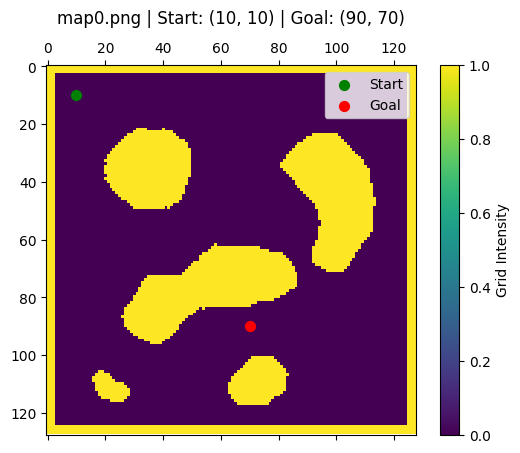

In [3]:
# User input for map selection
print("Select a map:")
for i in range(len(maps)):
    print(f"{i}: {maps[i]['filename']}")

try:
    choice = int(input("Enter the map number (0-3): "))
    if choice not in maps:
        raise ValueError("Invalid choice. Please enter a number between 0 and 3.")
    selected_map = maps[choice]
except Exception as e:
    print(f"Error: {e}")
    exit()

print('---------------------------------------------------------')
print("you have entered:", choice)
print("Selected map with start and goal point is:", selected_map)

# Load and process the selected grid map
try:
    image = Image.open(selected_map["filename"]).convert('L')
    grid_map = np.array(image.getdata()).reshape(image.size[1], image.size[0]) / 255

    # Binarize and invert the grid map
    grid_map[grid_map > 0.5] = 1
    grid_map[grid_map <= 0.5] = 0
    grid_map = (grid_map * -1) + 1
except Exception as e:
    print(f"Error loading or processing the map: {e}")
    exit()

#Start and Goal points 
start = selected_map["start"]
goal = selected_map["goal"]

# Display grid map
plt.matshow(grid_map, cmap='viridis', fignum=0)
plt.scatter(start[1], start[0], c='green', s=50, label='Start')
plt.scatter(goal[1], goal[0], c='red', s=50, label='Goal')
plt.colorbar
plt.title(f"{selected_map['filename']} | Start: {start} | Goal: {goal}", pad=30)
plt.legend(loc='upper right')
plt.colorbar(label='Grid Intensity')
plt.show()

## <span style="color:blue;">Part B: RRT Code</span>
***Implement and execute the Rapidly-exploring Random Tree (RRT) algorithm.***
---

In [4]:
# Define the Point class for representing points in 2D space
class Point:
    """
    Represents a 2D point with utility methods.
    """
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def to_tuple(self):
        return (self.x, self.y)

    def distance_to(self, other):
        """Compute Euclidean distance to another point."""
        return np.linalg.norm([self.x - other.x, self.y - other.y])

In [5]:
# Define helper functions
def fill_path(states, edges):
    """Backtrack to find the path from goal to start."""
    edges.reverse()
    path = [edges[0][1]]
    next_v = edges[0][0]
    i = 1
    while next_v != 0:
        while edges[i][1] != next_v:
            i += 1
        path.append(edges[i][1])
        next_v = edges[i][0]
    path.append(0)
    edges.reverse()
    path.reverse()
    return path

def is_segment_free(qnear, qnew, grid_map):
    """
    Check if the segment between two points is collision-free.
    """
    segment = np.linspace([qnear.x, qnear.y], [qnew.x, qnew.y], num=100)  # Higher resolution
    for point in segment:
        x, y = int(round(point[0])), int(round(point[1]))
        if not (0 <= x < grid_map.shape[0] and 0 <= y < grid_map.shape[1]):
            return False  # Out of bounds
        if grid_map[x, y] == 1:  # Collision with obstacle
            return False
    return True

def smooth_path(path, states, grid_map):
    """
    Smooth the path by removing unnecessary waypoints while avoiding obstacles.
    """
    last = len(path) - 1  # Start from the goal
    first = 0
    smoothed_path = []

    while last != 0:
        # Check if the edge between 'path[last]' and 'path[first]' is free
        while not is_segment_free(states[path[first]], states[path[last]], grid_map):
            first += 1  # Increment 'first' until a valid edge is found

        # Add the 'last' point to the smoothed path
        smoothed_path.append(path[last])
        
        # Update 'last' and reset 'first'
        last = first
        first = 0

    # Add the start point to the path
    smoothed_path.append(path[0])
    smoothed_path.reverse()  # Reverse the path to go from start to goal
    return smoothed_path

def nearest_vertex(qrand, states):
    """Find the nearest vertex in states to qrand."""
    distances = [qrand.distance_to(state) for state in states]
    return np.argmin(distances)

def compute_path_distance(path, states):
    """Compute the total distance of a path."""
    return sum(states[path[i]].distance_to(states[path[i + 1]]) for i in range(len(path) - 1))

In [6]:
#RRT function
def rrt_with_iterations(grid_map, qstart, qgoal, delta_q, max_iter, p):
    """Run the RRT algorithm with iteration feedback."""
    states = [qstart]
    edges = []
    for i in range(max_iter):
        # Random sampling
        if np.random.rand() < p:  # Probability to sample qgoal
            qrand = qgoal
        else:
            qrand = Point(
                np.random.randint(0, grid_map.shape[0]),
                np.random.randint(0, grid_map.shape[1]),
            )

        # Find nearest vertex
        qnear_idx = nearest_vertex(qrand, states)
        qnear = states[qnear_idx]

        # Generate new configuration
        direction = np.array([qrand.x - qnear.x, qrand.y - qnear.y])
        norm = np.linalg.norm(direction)
        if norm > delta_q:
            direction = direction / norm * delta_q
        qnew = Point(int(qnear.x + direction[0]), int(qnear.y + direction[1]))

        # Collision check and add new vertex/edge
        if is_segment_free(qnear, qnew, grid_map):
            if 0 <= qnew.x < grid_map.shape[0] and 0 <= qnew.y < grid_map.shape[1]:
                states.append(qnew)
                edges.append((qnear_idx, len(states) - 1))

                # Check if goal is reached
                if qnew.distance_to(qgoal) < delta_q:
                    states.append(qgoal)
                    edges.append((len(states) - 2, len(states) - 1))
                    path = fill_path(states, edges)
                    distance = compute_path_distance(path, states)
                    return states, edges, path, i + 1  # Return iteration where goal is reached
    print("No solution found. Please increase max iterations (K).")
    return states, edges, [], None

You Entered Maximum Iteration = 1500
Goal reached at iteration: 181
Path distance: 166.31084587282655
path points:[0, 1, 3, 4, 8, 9, 11, 12, 14, 17, 18, 19, 20, 22, 25, 27, 29, 30, 31, 32, 35, 37, 39, 49, 51, 53, 72, 82, 84, 95, 98, 102, 104, 108, 109, 111, 112, 113, 115, 116]
path to follow
(10.00, 10.00)
(14.00, 13.00)
(12.00, 17.00)
(11.00, 21.00)
(10.00, 25.00)
(11.00, 29.00)
(11.00, 33.00)
(12.00, 37.00)
(15.00, 40.00)
(17.00, 44.00)
(17.00, 49.00)
(19.00, 53.00)
(22.00, 56.00)
(26.00, 57.00)
(30.00, 57.00)
(34.00, 58.00)
(36.00, 62.00)
(40.00, 62.00)
(44.00, 62.00)
(48.00, 62.00)
(52.00, 64.00)
(56.00, 64.00)
(60.00, 64.00)
(62.00, 68.00)
(62.00, 72.00)
(62.00, 77.00)
(61.00, 81.00)
(61.00, 85.00)
(61.00, 89.00)
(65.00, 91.00)
(69.00, 89.00)
(73.00, 91.00)
(77.00, 89.00)
(79.00, 84.00)
(83.00, 84.00)
(85.00, 79.00)
(89.00, 76.00)
(93.00, 74.00)
(90.00, 70.00)
(90.00, 70.00)


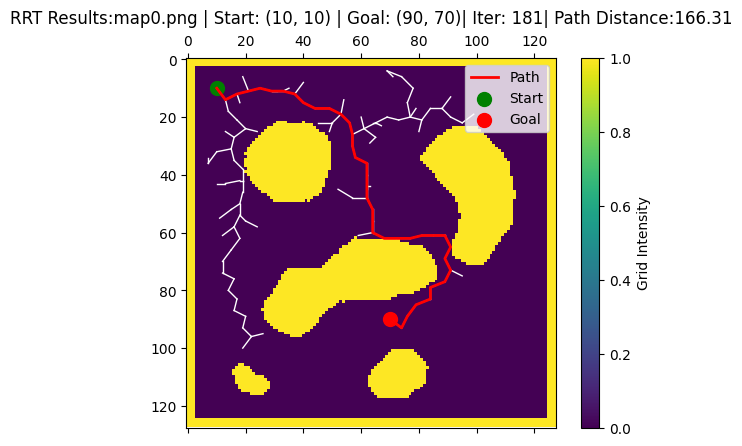

In [7]:
# User input for maximum iterations (K)
try:
    K = int(input("Enter the maximum number of iterations (K) for RRT: "))
    if K <= 0:
        raise ValueError("The number of iterations must be a positive integer.")
except Exception as e:
    print(f"Invalid input: {e}")
    exit()

print(f"You Entered Maximum Iteration = {K}")

# other Parameters
delta_q = 5
p = 0.2

# Run RRT function
states, edges, path, goal_iteration = rrt_with_iterations(grid_map, Point(*start), Point(*goal), delta_q, K, p)

# Print path results and iterations
if goal_iteration is not None:
    print(f"Goal reached at iteration: {goal_iteration}")
    path_distance = compute_path_distance(path, states)
    print(f"Path distance: {path_distance}")
    print(f"path points:{path}")
    print("path to follow")
    for p in path:
        print(f"({states[p].x:.2f}, {states[p].y:.2f})")

# Visualization of RRT Results
plt.matshow(grid_map, cmap='viridis', fignum=0)
for edge in edges: # Plot the tree
    start_node, end_node = states[edge[0]], states[edge[1]]
    plt.plot([start_node.y, end_node.y], [start_node.x, end_node.x], 'w-', linewidth=1)
if path: # Plot the path
    path_coords = [(states[node].x, states[node].y) for node in path]
    path_x, path_y = zip(*path_coords)
    plt.plot(path_y, path_x, 'r-', linewidth=2, label='Path')
plt.scatter(start[1], start[0], c='green', s=100, label='Start') # Mark start
plt.scatter(goal[1], goal[0], c='red', s=100, label='Goal')  #goal points
plt.title(f"RRT Results:{selected_map['filename']} | Start: {start} | Goal: {goal}| Iter: {goal_iteration}| Path Distance:{path_distance:.2f}", pad=25)
plt.legend(loc='upper right')
plt.colorbar(label='Grid Intensity')
plt.show()


Smoothed Path found in 5 points
Smoothed Distance: 134.67
Smoothed PATH to follow:
(10.00, 10.00)
(11.00, 33.00)
(61.00, 85.00)
(77.00, 89.00)
(90.00, 70.00)


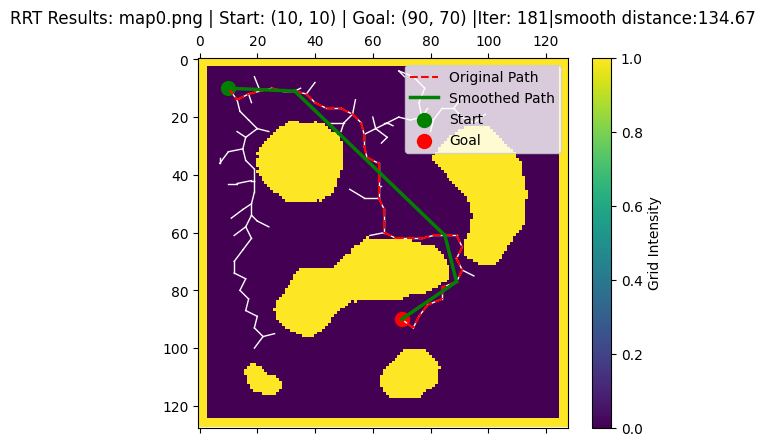

In [8]:
# Smooth the path
smoothed_path_indices = smooth_path(path, states, grid_map)

# Print smoothed path details
smoothed_path_distance = compute_path_distance(smoothed_path_indices, states)
print(f"Smoothed Path found in {len(smoothed_path_indices)} points")
print(f"Smoothed Distance: {smoothed_path_distance:.2f}")
print("Smoothed PATH to follow:")
for idx in smoothed_path_indices:
    print(f"({states[idx].x:.2f}, {states[idx].y:.2f})")

# Visualization for Original and Smoothed Path
plt.matshow(grid_map, cmap='viridis', fignum=0)

# Plot the tree (white line)
for edge in edges:
    start_node, end_node = states[edge[0]], states[edge[1]]
    plt.plot([start_node.y, end_node.y], [start_node.x, end_node.x], 'w-', linewidth=1)

# Original path (red dotted line)
for i in range(1, len(path)):
    plt.plot(
        [states[path[i - 1]].y, states[path[i]].y],
        [states[path[i - 1]].x, states[path[i]].x],
        "--r",label="Original Path" if i == 1 else "")

# Smoothed path (solid green line)
for i in range(1, len(smoothed_path_indices)):
    plt.plot(
        [states[smoothed_path_indices[i - 1]].y, states[smoothed_path_indices[i]].y],
        [states[smoothed_path_indices[i - 1]].x, states[smoothed_path_indices[i]].x],
        "g-",linewidth=2.5,label="Smoothed Path" if i == 1 else "")

plt.scatter(start[1], start[0], c='green', s=100, label='Start')  # Start
plt.scatter(goal[1], goal[0], c='red', s=100, label='Goal')  # Goal
plt.title(f"RRT Results: {selected_map['filename']} | Start: {start} | Goal: {goal} |Iter: {goal_iteration}|smooth distance:{smoothed_path_distance:.2f}",pad=25)
plt.legend(loc='upper right')
plt.colorbar(label='Grid Intensity')
plt.show()


## <span style="color:blue;">Part C: RRT\* Code</span>
***Upgrade the RRT algorithm to find an optimal path using RRT\****
---

In [9]:
# Node class definition
class Node:
    """Represents a node in the RRT* tree."""
    def __init__(self, point, parent=None, cost=0):
        self.point = point
        self.parent = parent
        self.cost = cost

In [10]:
# Function to check if a point is free space
def is_free(point, grid_map):
    """Check if a point is in a free space."""
    x, y = int(point[0]), int(point[1])
    if x < 0 or y < 0 or x >= grid_map.shape[1] or y >= grid_map.shape[0]:
        return False
    return grid_map[y, x] == 0

# Steer function to move towards q_rand
def steer(q_nearest, q_rand, delta_q):
    """Steer towards q_rand from q_nearest by a step size delta_q."""
    direction = np.array(q_rand) - np.array(q_nearest)
    distance = np.linalg.norm(direction)
    if distance <= delta_q:
        return q_rand
    step = direction / distance * delta_q
    return tuple(np.array(q_nearest) + step)

# Get near nodes function
def get_near_nodes(tree, q_new, max_distance):
    """Find nearby nodes within max_distance of q_new."""
    return [node for node in tree if np.linalg.norm(np.array(node.point) - np.array(q_new)) <= max_distance]

# Collision-free function to check the path between nodes
def collision_free(q1, q2, grid_map):
    """Check if the line segment between q1 and q2 is collision-free."""
    x1, y1 = q1
    x2, y2 = q2
    steps = int(np.linalg.norm(np.array(q1) - np.array(q2)))
    for t in np.linspace(0, 1, steps):
        x = int(x1 + t * (x2 - x1))
        y = int(y1 + t * (y2 - y1))
        if not is_free((x, y), grid_map):
            return False
    return True

In [11]:
# Main RRT* algorithm
def rrt_star(grid_map, start, goal, K, delta_q, p, max_distance):
    """Run the RRT* algorithm."""
    start = (start[1], start[0])
    goal = (goal[1], goal[0])
    start_node = Node(start)
    goal_node = Node(goal)
    tree = [start_node] # Tree at initial
    tree_at_goal = None  # Tree for  state when the goal is reached
    path_to_goal = []   # Fath at initial
    path_to_goal_full = []  # Path for state when the goal is reached
    goal_reached_iteration = None 

    sampled_points = []  # For visualization of all sampled points

    for iteration in range(K):
        # Sample q_rand
        if random.random() < p:
            q_rand = goal
        else:
            q_rand = (random.randint(0, grid_map.shape[1] - 1), random.randint(0, grid_map.shape[0] - 1))
        sampled_points.append(q_rand)
        if not is_free(q_rand, grid_map):
            continue

        # Find the nearest node
        q_nearest = min(tree, key=lambda node: np.linalg.norm(np.array(node.point) - np.array(q_rand)))

        # Steer towards q_rand
        q_new = steer(q_nearest.point, q_rand, delta_q)
        if not is_free(q_new, grid_map) or not collision_free(q_nearest.point, q_new, grid_map):
            continue

        # Find near nodes
        near_nodes = get_near_nodes(tree, q_new, max_distance)

        # Add q_new to the tree
        q_new_node = Node(q_new, q_nearest, q_nearest.cost + np.linalg.norm(np.array(q_new) - np.array(q_nearest.point)))
        tree.append(q_new_node)

        # Rewire the tree
        for near_node in near_nodes:
            if collision_free(near_node.point, q_new, grid_map) and \
               near_node.cost + np.linalg.norm(np.array(q_new) - np.array(near_node.point)) < q_new_node.cost:
                q_new_node.parent = near_node
                q_new_node.cost = near_node.cost + np.linalg.norm(np.array(q_new) - np.array(near_node.point))

        for near_node in near_nodes:
            if collision_free(near_node.point, q_new, grid_map) and \
               q_new_node.cost + np.linalg.norm(np.array(near_node.point) - np.array(q_new)) < near_node.cost:
                near_node.parent = q_new_node
                near_node.cost = q_new_node.cost + np.linalg.norm(np.array(near_node.point) - np.array(q_new))

        if goal_reached_iteration is None and np.linalg.norm(np.array(q_new) - np.array(goal)) <= delta_q:
            if collision_free(q_new, goal, grid_map):
                goal_node.parent = q_new_node
                goal_node.cost = q_new_node.cost + np.linalg.norm(np.array(goal) - np.array(q_new))
                tree.append(goal_node)
                goal_reached_iteration = iteration  # Track when the goal was reached
                tree_at_goal = tree[:]  # Save the tree state when the goal is first reached
                # Extract path to goal
                current = goal_node
                while current is not None:
                    path_to_goal.append(current.point)
                    current = current.parent
                path_to_goal.reverse()

    # Extract full tree path
    path_to_goal_full = []
    if goal_node in tree:
        current = goal_node
        while current is not None:
            path_to_goal_full.append(current.point)
            current = current.parent
        path_to_goal_full.reverse()

    return path_to_goal, path_to_goal_full,tree_at_goal, tree, goal_reached_iteration

In [12]:
#User input value for maximum iterations (K)
try:
    K = int(input("Enter the maximum number of iterations (K) for RRT_STAR*: "))
    if K <= 0:
        raise ValueError("The number of iterations must be a positive integer.")
except Exception as e:
    print(f"Invalid input: {e}")
    exit()

print(f"You Entered Maximum Iteration = {K}")
#K = 10000
delta_q = 5
p = 0.2
max_distance = 30

path_to_goal, path_to_goal_full, tree_at_goal,tree, goal_reached_iteration = rrt_star(grid_map, start, goal, K, delta_q, p, max_distance)

You Entered Maximum Iteration = 1500


Delta_q: 5, p: 0.2, Max_distance: 30
Goal reached at iteration: 388
Path distance to goal: 131.77655568040288


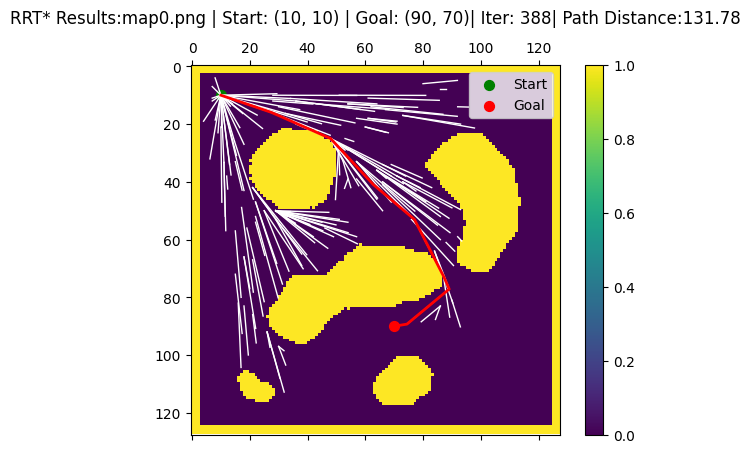

-------------------------------------------
Maximum Iteration= 1500
Path distance for maximum iterations path: 130.69197790802298


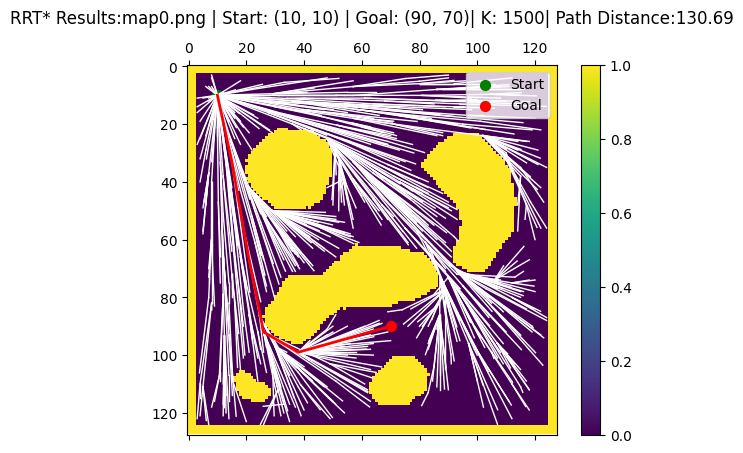

In [13]:
# Print results
print(f"Delta_q: {delta_q}, p: {p}, Max_distance: {max_distance}")
if goal_reached_iteration is not None:
    print(f"Goal reached at iteration: {goal_reached_iteration}")
else:
    print("Goal not reached. Please  increase max iterations (K).")

# Calculate and print path distances for goal reach iterations
if path_to_goal:
    path_distance_to_goal = sum(np.linalg.norm(np.array(path_to_goal[i + 1]) - np.array(path_to_goal[i]))
                                for i in range(len(path_to_goal) - 1))
    print(f"Path distance to goal: {path_distance_to_goal}")

# Visualize the result for goal reached iteration
if path_to_goal:
    plt.matshow(grid_map, cmap='viridis',fignum=0)
    for node in tree_at_goal:
        if node.parent:
            plt.plot([node.point[0], node.parent.point[0]], [node.point[1], node.parent.point[1]], 'w-', linewidth=1)
    plt.plot(*zip(*path_to_goal), 'r-', linewidth=2)
    plt.scatter(start[1], start[0], c='green', s=50, label='Start')
    plt.scatter(goal[1], goal[0], c='red', s=50, label='Goal')
    #plt.title(f"Goal reached at iteration: {goal_reached_iteration}")
    plt.title(f"RRT* Results:{selected_map['filename']} | Start: {start} | Goal: {goal}| Iter: {goal_reached_iteration}| Path Distance:{path_distance_to_goal:.2f}", pad=30)
    plt.legend(loc='upper right')
    plt.colorbar()
    plt.show()
 
# Calculate and print path distances for maximum iterations
print('-------------------------------------------')
print(f"Maximum Iteration= {K}")   
if path_to_goal_full:
    path_distance_full = sum(np.linalg.norm(np.array(path_to_goal_full[i + 1]) - np.array(path_to_goal_full[i]))
                             for i in range(len(path_to_goal_full) - 1))
    print(f"Path distance for maximum iterations path: {path_distance_full}")

# Visualize the result for maximum iterations
plt.matshow(grid_map, cmap='viridis',fignum=0)
for node in tree:
    if node.parent:
        plt.plot([node.point[0], node.parent.point[0]], [node.point[1], node.parent.point[1]], 'w-', linewidth=1)
if path_to_goal_full:
    plt.plot(*zip(*path_to_goal_full), 'r-', linewidth=2)
plt.scatter(start[1], start[0], c='green', s=50, label='Start')
plt.scatter(goal[1], goal[0], c='red', s=50, label='Goal')
#plt.title(f"Result after maximum iterations: {K}")
plt.title(f"RRT* Results:{selected_map['filename']} | Start: {start} | Goal: {goal}| K: {K}| Path Distance:{path_distance_full:.2f}", pad=30)
plt.legend(loc='upper right')
plt.colorbar()
plt.show()